# ***Load and Explore the Data***

## ***Importing Libraries***

In [229]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## ***Loading Dataset***

In [175]:
df = pd.read_csv("/content/drive/MyDrive/ICT Projects Ai & ML/Datasets/heart_disease.csv")

In [176]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [177]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [178]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [179]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [180]:
df.shape

(1025, 14)

In [181]:
# checking missing values

df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [182]:
(df.isnull().sum() / len(df)) * 100

,0
age,0.0
sex,0.0
cp,0.0
trestbps,0.0
chol,0.0
fbs,0.0
restecg,0.0
thalach,0.0
exang,0.0
oldpeak,0.0


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [184]:
df.duplicated().sum()

np.int64(723)

In [185]:
df = df.drop_duplicates()

### ***outliers in numerical columns***

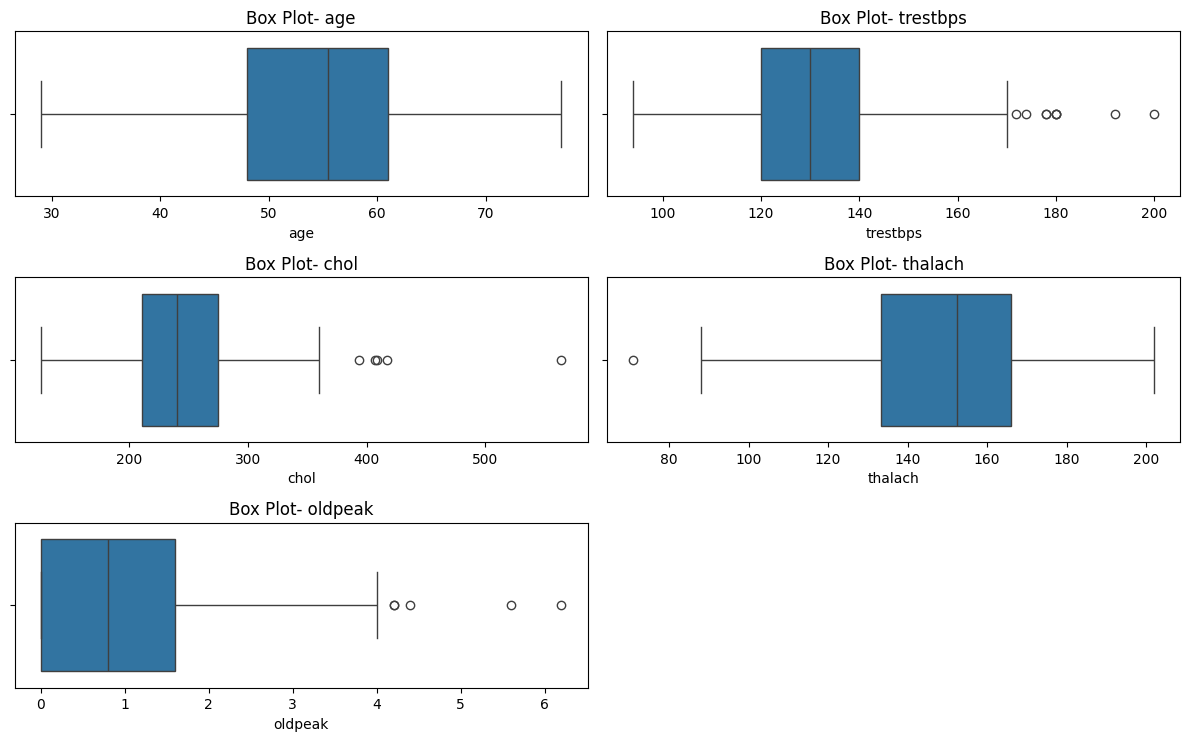

In [186]:
# Outliers

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(12,12))

for i, col in enumerate(num_cols):
  plt.subplot(len(num_cols), 2, i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot- {col}")

plt.tight_layout()
plt.show()

### ***Analyze the distribution of categorical variables***


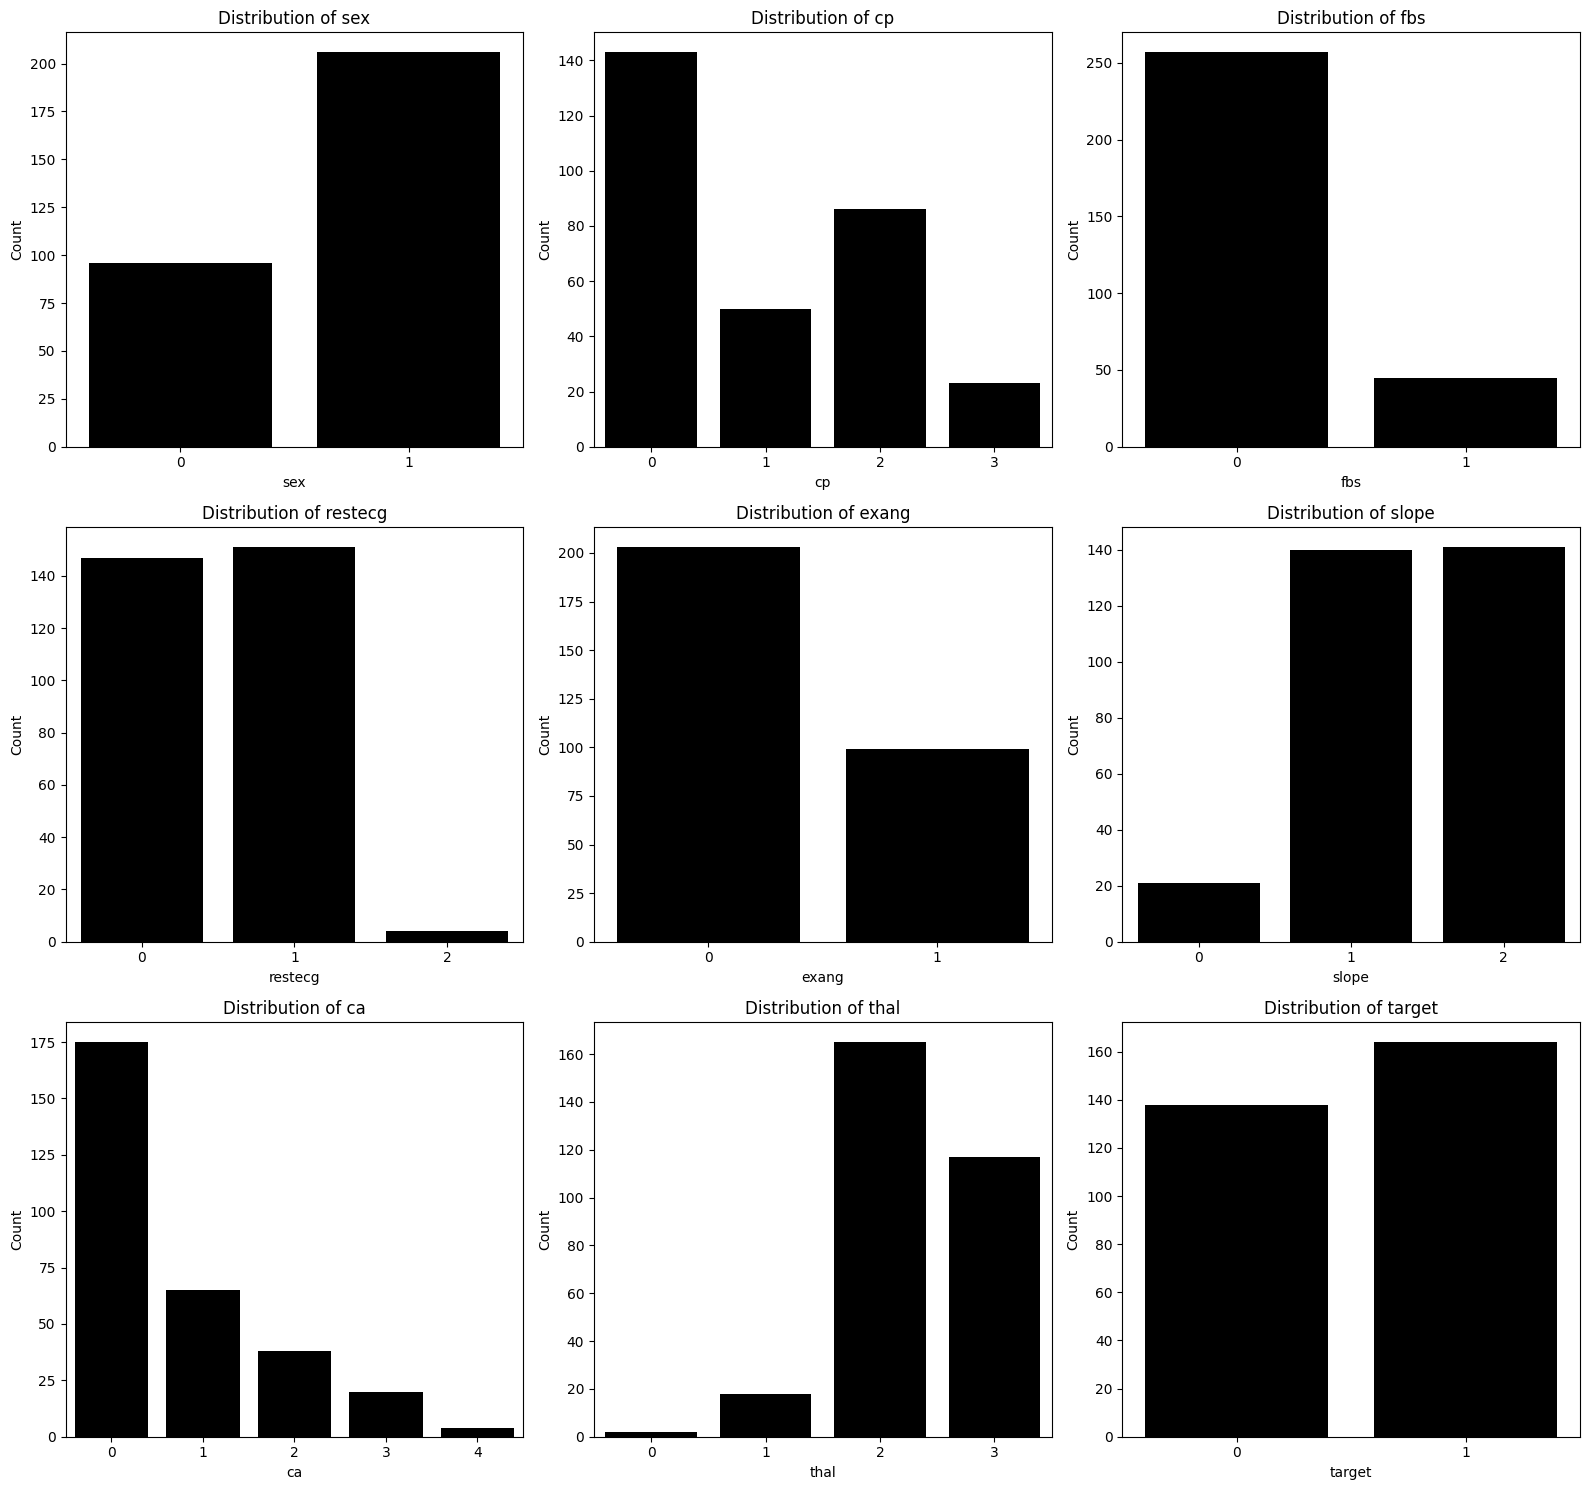

In [187]:
cat_cols = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal', 'target'
]

plt.figure(figsize=(16, 15))

for i, col in enumerate(cat_cols):

    plt.subplot(3, 3, i+1)

    counts = df[col].value_counts()

    sns.barplot(x=counts.index, y=counts.values, color="black")

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# ***Data Cleaning and Preprocessing***

### ***Handling Outliers***

In [188]:
# handling outliers

 # IQR Technique
 # find 1st and 3rd Quantile

for cols in num_cols:

# First and Third Qunatile

  Q1 = df[cols].quantile(0.25)
  Q3 = df[cols].quantile(0.75)

  # IQR
  IQR=Q3-Q1

  # Finding upper and lower bounds
  upper_bound = Q3 + 1.5 * IQR
  lower_bound = Q1 - 1.5 * IQR

  # Outlier
  outlier = df[(df[cols] < lower_bound) | (df[cols] > upper_bound) ]

  # Clipping
  df[cols] = df [cols].clip(upper = upper_bound,lower = lower_bound)


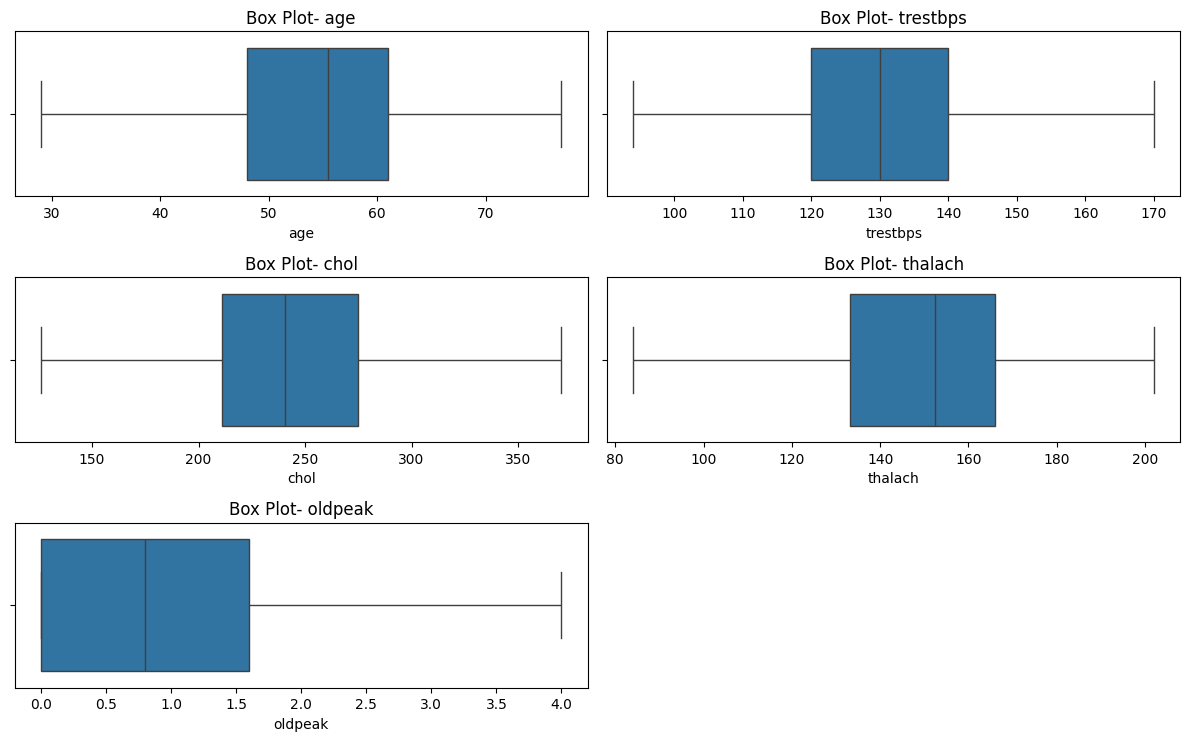

In [189]:
plt.figure(figsize=(12,12))

for i, col in enumerate(num_cols):
  plt.subplot(len(num_cols), 2, i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot- {col}")

plt.tight_layout()
plt.show()

### ***Encoding***

In [190]:
le = LabelEncoder()
oh = OneHotEncoder()

In [191]:
oh_cols = ['cp', 'restecg', 'thal']

oh = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

oh_encoded = pd.DataFrame(
    oh.fit_transform(df[oh_cols]),
    columns=oh.get_feature_names_out(oh_cols),
    index=df.index
)

In [192]:
oh_encoded.head()

,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [193]:
df = df.drop(columns=oh_cols).join(oh_encoded)

In [194]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212.0,0,168.0,0,1.0,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53,1,140,203.0,1,155.0,1,3.1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174.0,0,125.0,1,2.6,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,61,1,148,203.0,0,161.0,0,0.0,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,0,138,294.0,1,106.0,0,1.9,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [195]:
le_encoded = ["sex","fbs"]

le = LabelEncoder()

for col in le_encoded:
    df[col] = le.fit_transform(df[col])

### ***Scaling***

In [196]:
scale_cols = ["trestbps", "chol", "thalach", "oldpeak"]

In [197]:
scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

# ***Train Test Split***

### ***For Regression***

In [198]:
# Regression

X_reg = df.drop(['chol', 'target'], axis=1)

y_reg = df['chol']

In [199]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

### ***For Classification***

In [200]:
# Classification

X_cls = df.drop('target', axis=1)
y_cls = df['target']

In [201]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# ***Build Machine Learning Models***

## ***Regression Task***

### ***Lenear Regression***

In [202]:
lr = LinearRegression()

In [203]:
lr.fit(X_train_reg, y_train_reg)

LinearRegression()

In [204]:
y_pred_lr = lr.predict(X_test_reg)

### ***SVM***

In [205]:
svr = SVR(kernel='rbf')

In [206]:
svr.fit(X_train_reg, y_train_reg)

SVR()

In [207]:
y_pred_svr = svr.predict(X_test_reg)

### ***Random Forest***

In [208]:
rf_reg = RandomForestRegressor()

In [209]:
rf_reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor()

In [210]:
y_pred_rf_reg = rf_reg.predict(X_test_reg)

## ***Classification Task***

### ***Logistic Regression***

In [211]:
lg = LogisticRegression()

lg.fit(X_train_cls, y_train_cls)

y_pred_lg = lg.predict(X_test_cls)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### ***KNN***

In [212]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_cls, y_train_cls)

y_pred_knn = knn.predict(X_test_cls)

### ***Random Forrest***

In [215]:
rf_cls = RandomForestClassifier()

rf_cls.fit(X_train_cls, y_train_cls)

y_pred_rf_cls = rf_cls.predict(X_test_cls)

# ***Evaluate Models on Test Data***

## ***Regression Model Testing***

In [216]:
mae = mean_absolute_error(y_test_reg, y_pred_lr)

mse = mean_squared_error(y_test_reg, y_pred_lr)

r2 = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression Evaluation")
print("----------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Linear Regression Evaluation
----------------------------
MAE: 0.7280882800268322
MSE: 0.8514206906148347
R2 Score: -0.1959577403077557


## ***Classification Model Testing***

In [217]:
print("Logistic Regression")
print("-------------------")

print("Accuracy:", accuracy_score(y_test_cls, y_pred_lg))

print("Precision:", precision_score(y_test_cls, y_pred_lg))

print("Recall:", recall_score(y_test_cls, y_pred_lg))

print("F1-Score:", f1_score(y_test_cls, y_pred_lg))

Logistic Regression
-------------------
Accuracy: 0.8524590163934426
Precision: 0.875
Recall: 0.8484848484848485
F1-Score: 0.8615384615384616


In [218]:
print("KNN")
print("-----")

print("Accuracy:", accuracy_score(y_test_cls, y_pred_knn))

print("Precision:", precision_score(y_test_cls, y_pred_knn))

print("Recall:", recall_score(y_test_cls, y_pred_knn))

print("F1-Score:", f1_score(y_test_cls, y_pred_knn))

KNN
-----
Accuracy: 0.7704918032786885
Precision: 0.7714285714285715
Recall: 0.8181818181818182
F1-Score: 0.7941176470588235


In [220]:
print("Random Forest Classifier")
print("------------------------")

print("Accuracy:", accuracy_score(y_test_cls, y_pred_rf_cls))

print("Precision:", precision_score(y_test_cls, y_pred_rf_cls))

print("Recall:", recall_score(y_test_cls, y_pred_rf_cls))

print("F1-Score:", f1_score(y_test_cls, y_pred_rf_cls))

Random Forest Classifier
------------------------
Accuracy: 0.7868852459016393
Precision: 0.8125
Recall: 0.7878787878787878
F1-Score: 0.8


# ***Summarize***

In [230]:
regression_results = {
    'Model': [
        'Linear Regression',
        'SVR',
        'Random Forest'
    ],
    'MAE': [
        mean_absolute_error(y_test_reg, y_pred_lr),
        mean_absolute_error(y_test_reg, y_pred_svr),
        mean_absolute_error(y_test_reg, y_pred_rf_reg)
    ],
    'MSE': [
        mean_squared_error(y_test_reg, y_pred_lr),
        mean_squared_error(y_test_reg, y_pred_svr),
        mean_squared_error(y_test_reg, y_pred_rf_reg)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
    ],
    'R2 Score': [
        r2_score(y_test_reg, y_pred_lr),
        r2_score(y_test_reg, y_pred_svr),
        r2_score(y_test_reg, y_pred_rf_reg)
    ]
}

regression_df = pd.DataFrame(regression_results)

regression_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.728088,0.851421,0.922725,-0.195958
1,SVR,0.657910,0.683602,0.826802,0.039770
2,Random Forest,0.691256,0.776202,0.881023,-0.090300


In [231]:
results = {
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test_cls, y_pred_lg),
        accuracy_score(y_test_cls, y_pred_knn),
        accuracy_score(y_test_cls, y_pred_rf_cls)
    ],

    'Precision': [
        precision_score(y_test_cls, y_pred_lg),
        precision_score(y_test_cls, y_pred_knn),
        precision_score(y_test_cls, y_pred_rf_cls)
    ],

    'Recall': [
        recall_score(y_test_cls, y_pred_lg),
        recall_score(y_test_cls, y_pred_knn),
        recall_score(y_test_cls, y_pred_rf_cls)
    ],

    'F1-Score': [
        f1_score(y_test_cls, y_pred_lg),
        f1_score(y_test_cls, y_pred_knn),
        f1_score(y_test_cls, y_pred_rf_cls)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.852459,0.875000,0.848485,0.861538
1,KNN,0.770492,0.771429,0.818182,0.794118
2,Random Forest,0.786885,0.812500,0.787879,0.800000


In [232]:
best_regression_model = regression_df.loc[
    regression_df['R2 Score'].idxmax()
]

print("Best Regression Model:")
print(best_regression_model)

Best Regression Model:
Model            SVR
MAE          0.65791
MSE         0.683602
RMSE        0.826802
R2 Score     0.03977
Name: 1, dtype: object


In [235]:
best_classification_model = results_df.loc[
    results_df['F1-Score'].idxmax()
]

print("Best Classification Model:")
print(best_classification_model)

Best Classification Model:
Model        Logistic Regression
Accuracy                0.852459
Precision                  0.875
Recall                  0.848485
F1-Score                0.861538
Name: 0, dtype: object


In [238]:
print("\nBEST REGRESSION MODEL")
print("Model:", best_regression_model['Model'])
print("R2 Score:", best_regression_model['R2 Score'])
print("\n")
print("BEST CLASSIFICATION MODEL")
print("Model:", best_classification_model['Model'])
print("F1-Score:", best_classification_model['F1-Score'])


BEST REGRESSION MODEL
Model: SVR
R2 Score: 0.039770367437325316


BEST CLASSIFICATION MODEL
Model: Logistic Regression
F1-Score: 0.8615384615384616
